In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [14]:
complete_df = pd.read_csv("../data/main/COMPLETE_edc_artist_and_stats.csv")
complete_df.head()

,artist,followers,streams,playlists,playlist reach,charts,shazams,videos,views,dj supports,total_appearances,years_played,agency
0,1080p,6,5986,1,641,0,17,45,9800,0,1,2024,insomniac
1,a shade of black,0,15100,0,11000,7,0,0,0,0,1,2024,NaN
2,aaron k,1,2163,0,0,1,4,2,0,0,2,"2024, 2025",insomniac
3,abana,7710,468000,175,4220000,60,15300,110,1890000,93,3,"2022, 2023, 2024",insomniac
4,d. zeledon,5776,69600,25,218000,18,764,31,9672,58,1,2024,insomniac


Pie chart reperesenting how many percent of each agency


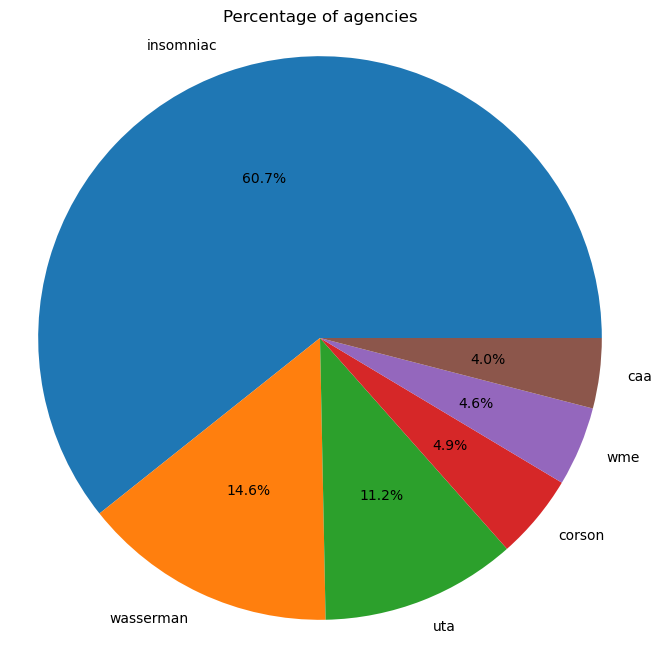

In [22]:
agency = complete_df['agency']      # The values for each slice

# Plot the pie chart
plt.figure(figsize=(8, 8)) # Optional: Adjust the figure size
plt.pie(
    agency.value_counts(),  # The values for each slice
    labels=agency.value_counts().index,
    autopct='%1.1f%%',  # Display percentage values on the slices
)

plt.title('Percentage of agencies') # Add a title to the chart
plt.axis('equal') # Ensures the pie chart is drawn as a perfect circle
plt.show() # Display the chart

## Top Artists Bar Charts
Top 10 artists by streams, followers, and total appearances

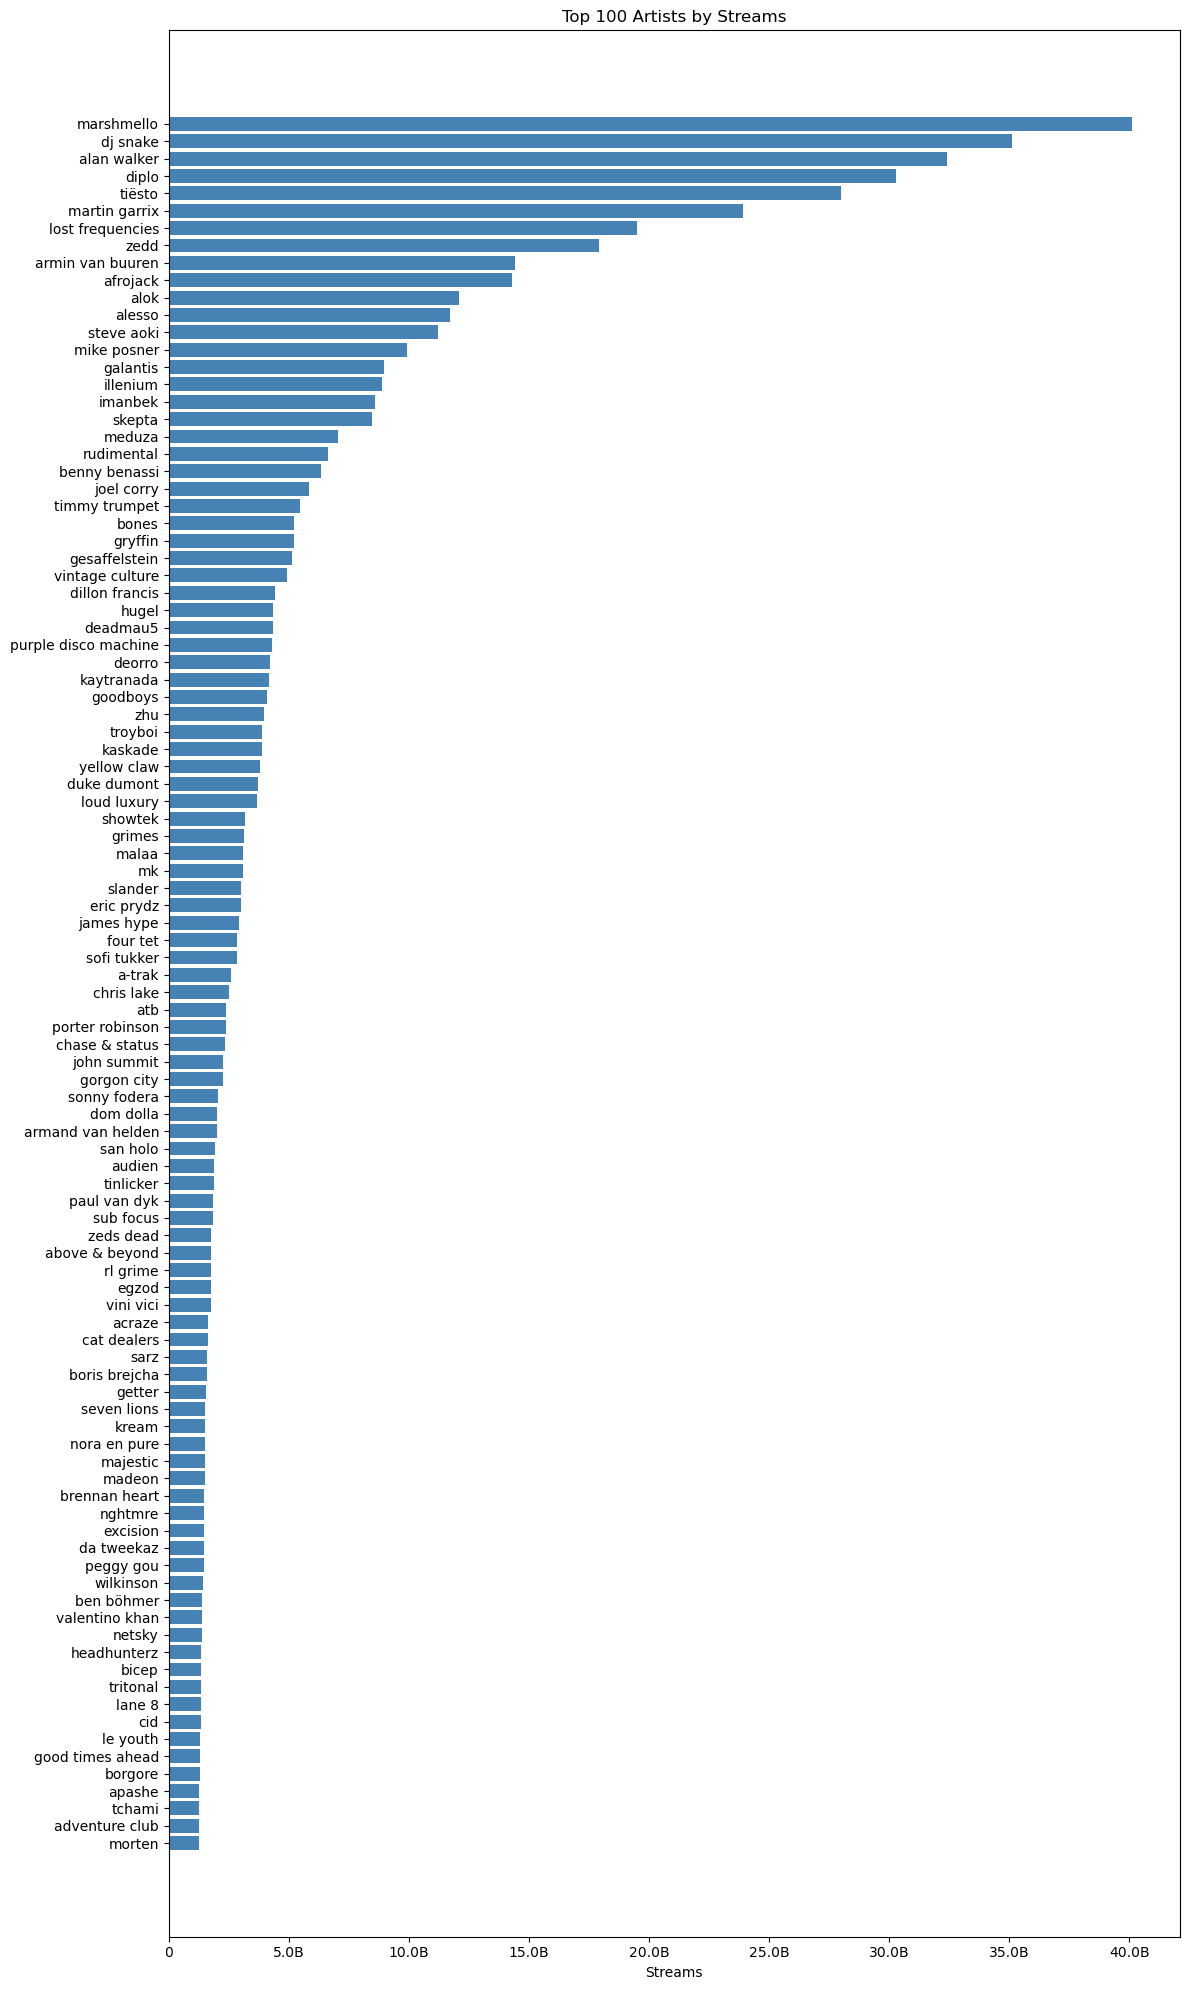

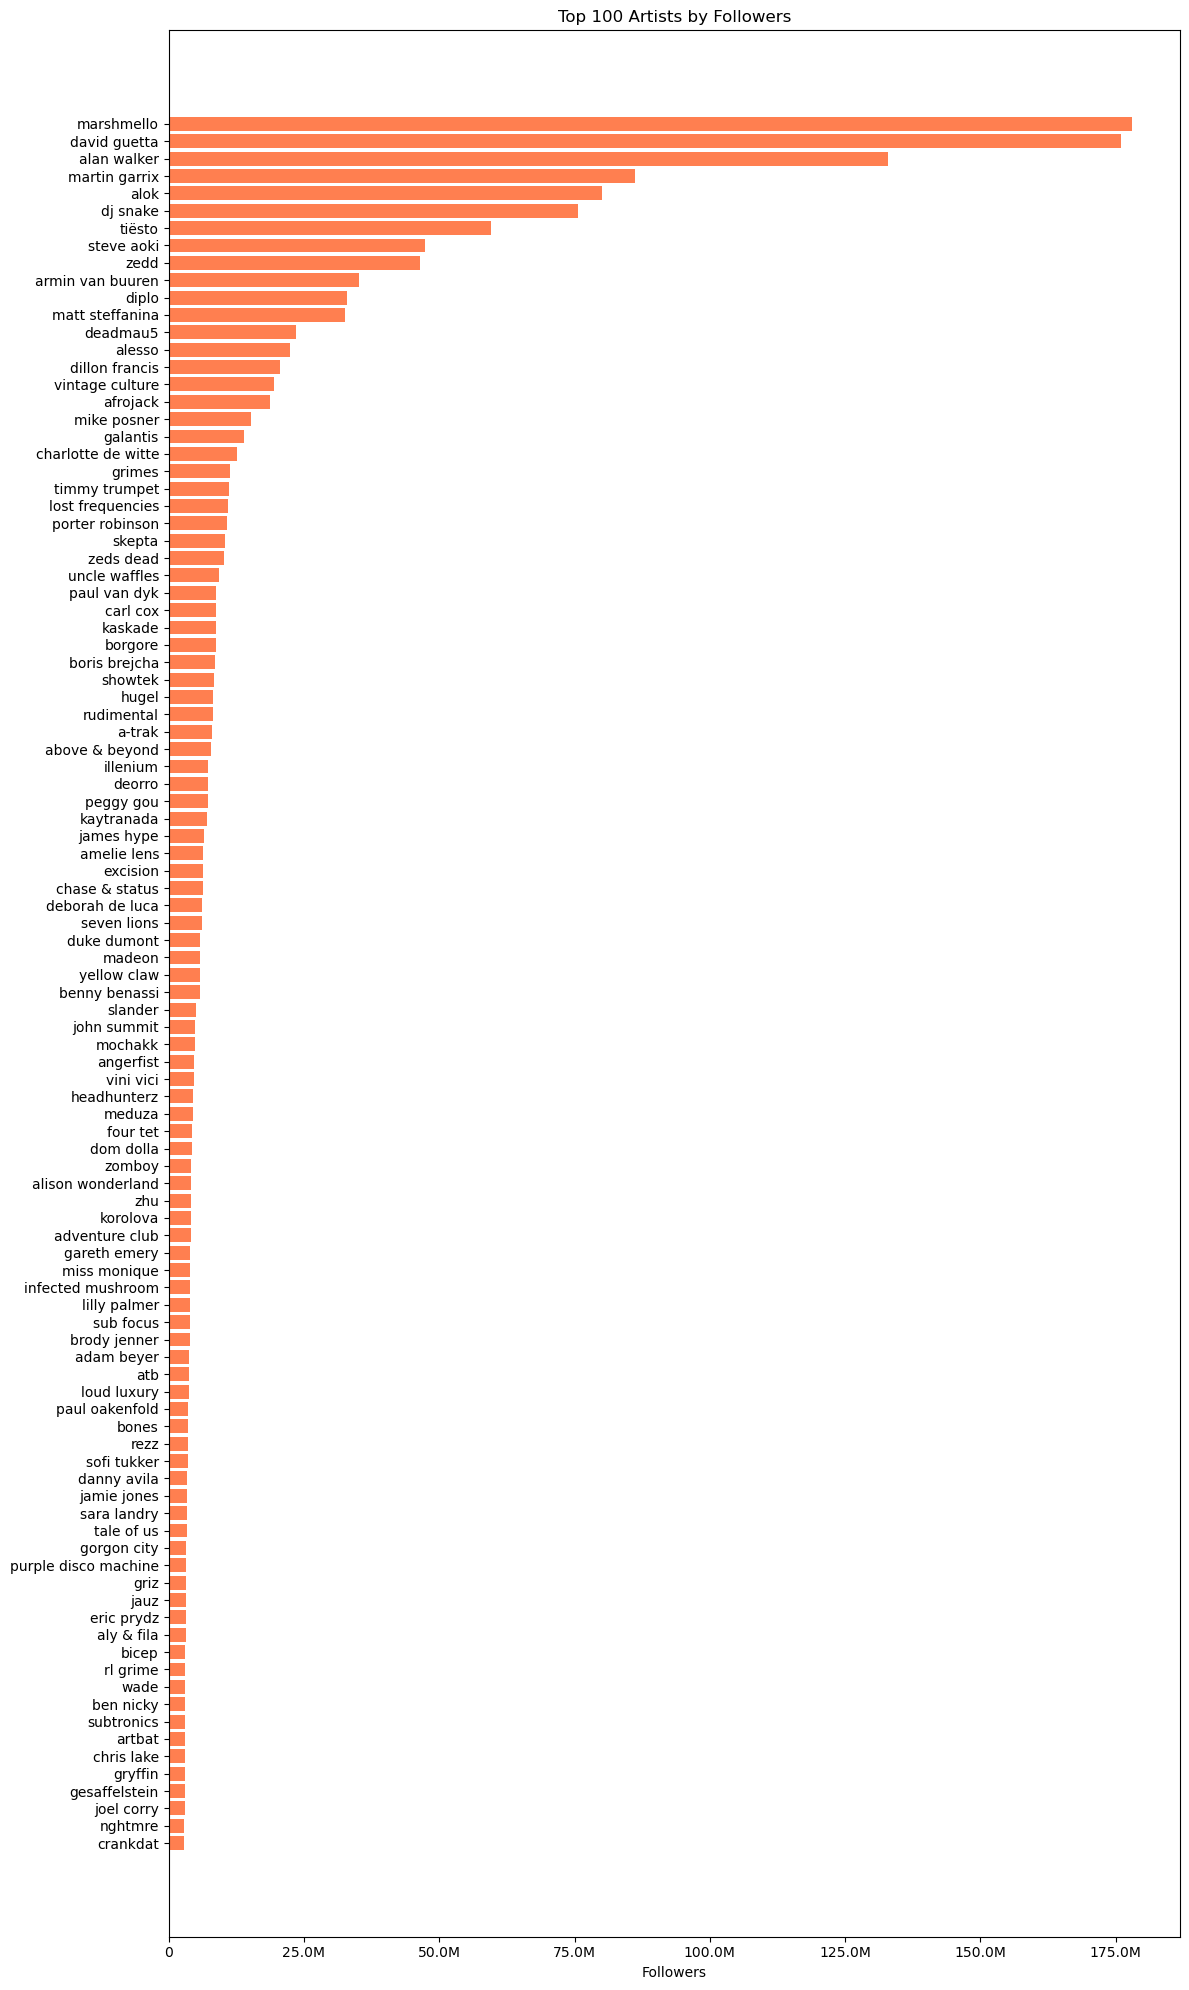

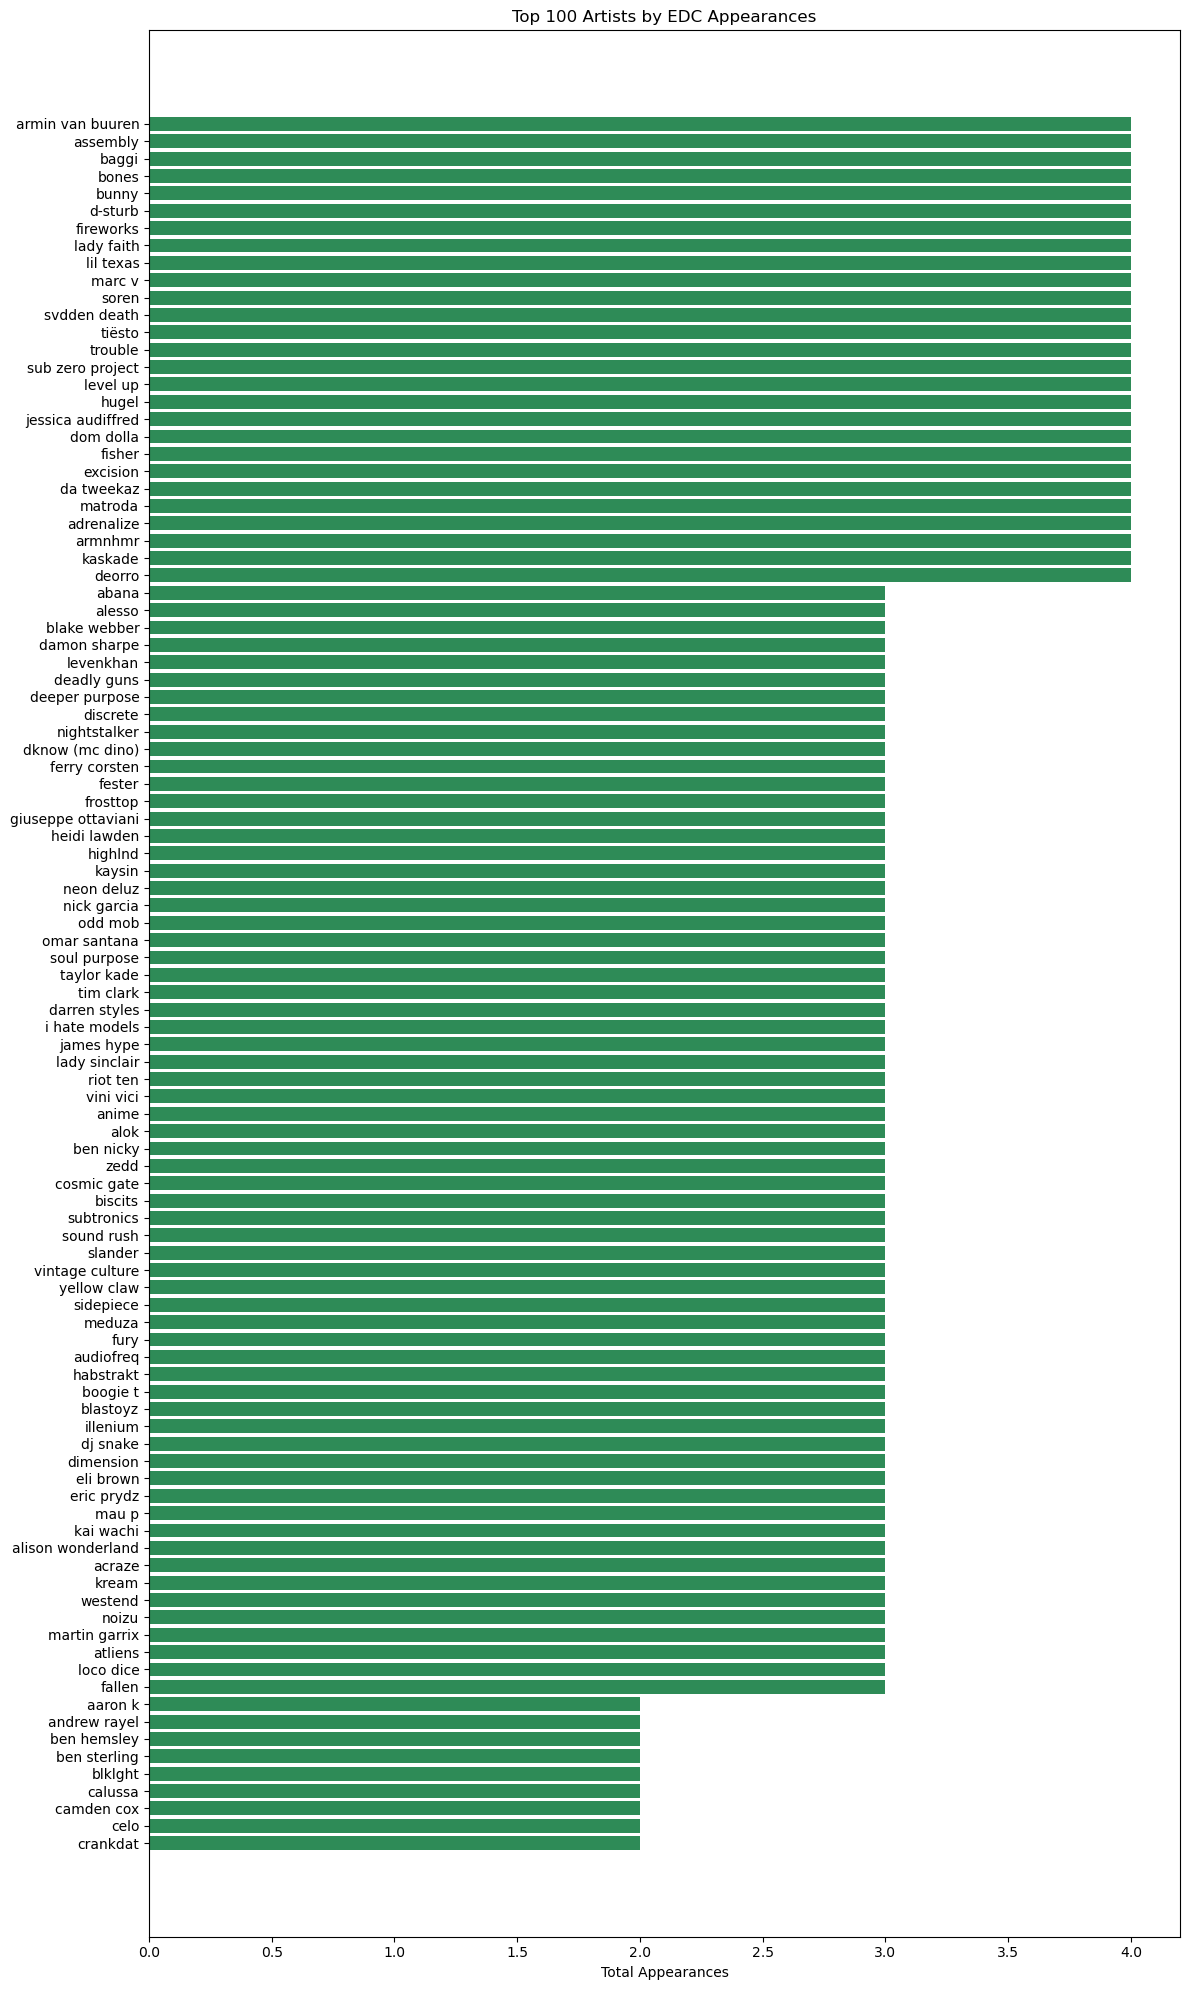

In [20]:
# Remove duplicates to get unique artists (keep first occurrence)
unique_artists = complete_df.drop_duplicates(subset='artist', keep='first')

# Function to format x-axis labels
def human_readable_format(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    else:
        return f'{x:.0f}'

from matplotlib.ticker import FuncFormatter

# Top 100 by Streams
plt.figure(figsize=(12, 20))
top_streams = unique_artists.nlargest(100, 'streams')[['artist', 'streams']]
plt.barh(top_streams['artist'], top_streams['streams'], color='steelblue')
plt.xlabel('Streams')
plt.title('Top 100 Artists by Streams')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(FuncFormatter(human_readable_format))
plt.tight_layout()
plt.show()

# Top 100 by Followers
plt.figure(figsize=(12, 20))
top_followers = unique_artists.nlargest(100, 'followers')[['artist', 'followers']]
plt.barh(top_followers['artist'], top_followers['followers'], color='coral')
plt.xlabel('Followers')
plt.title('Top 100 Artists by Followers')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(FuncFormatter(human_readable_format))
plt.tight_layout()
plt.show()

# Top 100 by Total Appearances
plt.figure(figsize=(12, 20))
top_appearances = unique_artists.nlargest(100, 'total_appearances')[['artist', 'total_appearances']]
plt.barh(top_appearances['artist'], top_appearances['total_appearances'], color='seagreen')
plt.xlabel('Total Appearances')
plt.title('Top 100 Artists by EDC Appearances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()